# Proyek Data Mining: Klasifikasi Tingkat Risiko Penyakit Jantung
Notebook ini digunakan untuk menganalisis data rekam medis pasien dan melakukan klasifikasi risiko penyakit jantung menggunakan dua algoritma: **Decision Tree C4.5** dan **K-Nearest Neighbor (KNN)**.

## Langkah 1: Memuat Library Dasar untuk Eksplorasi Data (EDA)
Pada tahap awal ini, kita mengimpor beberapa pustaka utama seperti `pandas` untuk memproses tabel data, `numpy` untuk operasi matriks/angka, serta `matplotlib` untuk kebutuhan visualisasi grafik dasar.

In [1]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # Pustaka untuk plotting grafik
import numpy as np # Aljabar linear dan pemrosesan angka
import os # Mengakses struktur direktori file
import pandas as pd # Pemrosesan data tabel / DataFrame

print("Library dasar untuk EDA berhasil dimuat!")

Library dasar untuk EDA berhasil dimuat!


## Langkah 2: Membuat Fungsi Visualisasi Distribusi Kolom
Finsi ini dirancang untuk membuat grafik batang atau histogram secara otomatis untuk setiap fitur/kolom medis di dalam dataset. Fungsi ini membantu kita melihat sebaran data pasien secara visual.
*(Catatan: Kode pembagian pembentuk baris grafik telah diperbaiki menggunakan `//` agar menghasilkan angka bulat/integer).*

In [2]:
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]]
    nRow, nCol = df.shape
    columnNames = list(df)

    # Menggunakan '//' agar hasil pembagian berupa integer (angka bulat)
    nGraphRow = (nCol + nGraphPerRow - 1) // nGraphPerRow

    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(int(nGraphRow), int(nGraphPerRow), i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()

## Langkah 3: Membuat Fungsi Visualisasi Matriks Korelasi
Fungsi ini digunakan untuk mengukur seberapa kuat hubungan antar-parameter medis (misalnya hubungan antara usia dengan kadar kolesterol).
*(Catatan: Parameter `axis='columns'` dan `numeric_only=True` ditambahkan agar kompatibel dengan Pandas versi terbaru).*

In [3]:
# GANTI ISI CELL 6 DENGAN KODE MODERN INI:
import seaborn as sns

def plotCorrelationMatrix(df, graphWidth):
    filename = getattr(df, 'dataframeName', 'Dataset')

    # Membersihkan data dari kolom kosong
    df = df.dropna(axis='columns')
    df = df[[col for col in df if df[col].nunique() > 1]]

    # Menghitung matriks korelasi khusus angka
    corr = df.corr(numeric_only=True)

    # Membuat canvas grafik baru tanpa fignum manual (Aman dari Bug!)
    plt.figure(figsize=(graphWidth, graphWidth), dpi=100)

    # Membuat Heatmap yang cantik dengan warna Coolwarm dan menampilkan angka (annot=True)
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar_kws={"shrink": .8})

    plt.title(f'Correlation Matrix for {filename}', fontsize=14, pad=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Langkah 4: Membuat Fungsi Scatter dan Density Plot
Fungsi ini memetakan sebaran titik data rekam medis pasien dalam bentuk diagram sebar (*scatter plot*) untuk melihat pola pengelompokan awal data secara visual.

In [4]:
def plotScatterMatrix(df, plotSize, textSize):
    df = df.select_dtypes(include =[np.number])
    df = df.dropna(axis='columns') # Perbaikan parameter dropna bawaan pandas
    df = df[[col for col in df if df[col].nunique() > 1]]
    columnNames = list(df)
    if len(columnNames) > 10:
        columnNames = columnNames[:10]
    df = df[columnNames]
    ax = pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotSize, plotSize], diagonal='kde')
    corrs = df.corr().values
    for i, j in zip(*plt.np.triu_indices_from(ax, k = 1)):
        ax[i, j].annotate('Corr: %.2f' % corrs[i, j], (0.8, 0.2), xycoords='axes fraction', ha='center', va='center', size=textSize)
    plt.suptitle('Scatter and Density Plot')
    plt.show()

## Langkah 5: Membaca dan Memuat Dataset Rekam Medis (`heart.csv`)
Di sini kita akan memuat dataset `heart_new.csv` yang berisi tepat 303 sampel klinis pasien dari UCI Machine Learning Repository, sesuai dengan deskripsi data pada dokumen jurnal.

In [5]:
# Membaca dataset rekam medis klinis asli
df1 = pd.read_csv('heart.csv', delimiter=',')
df1.dataframeName = 'heart.csv'
nRow, nCol = df1.shape
print(f'Berhasil memuat data! Terdapat {nRow} baris dan {nCol} kolom pada dataset.')

Berhasil memuat data! Terdapat 1025 baris dan 14 kolom pada dataset.


## Langkah 6: Menampilkan Pratinjau 5 Data Pertama
Kita menampilkan 5 baris teratas dari dataset untuk memeriksa nama-nama kolom rekam medis dan tipe data awal yang disajikan.

In [6]:
df1.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Langkah 7: Eksekusi Grafik Distribusi Kolom
Menjalankan fungsi visualisasi untuk melihat bentuk sebaran frekuensi data pada masing-masing parameter rekam medis.

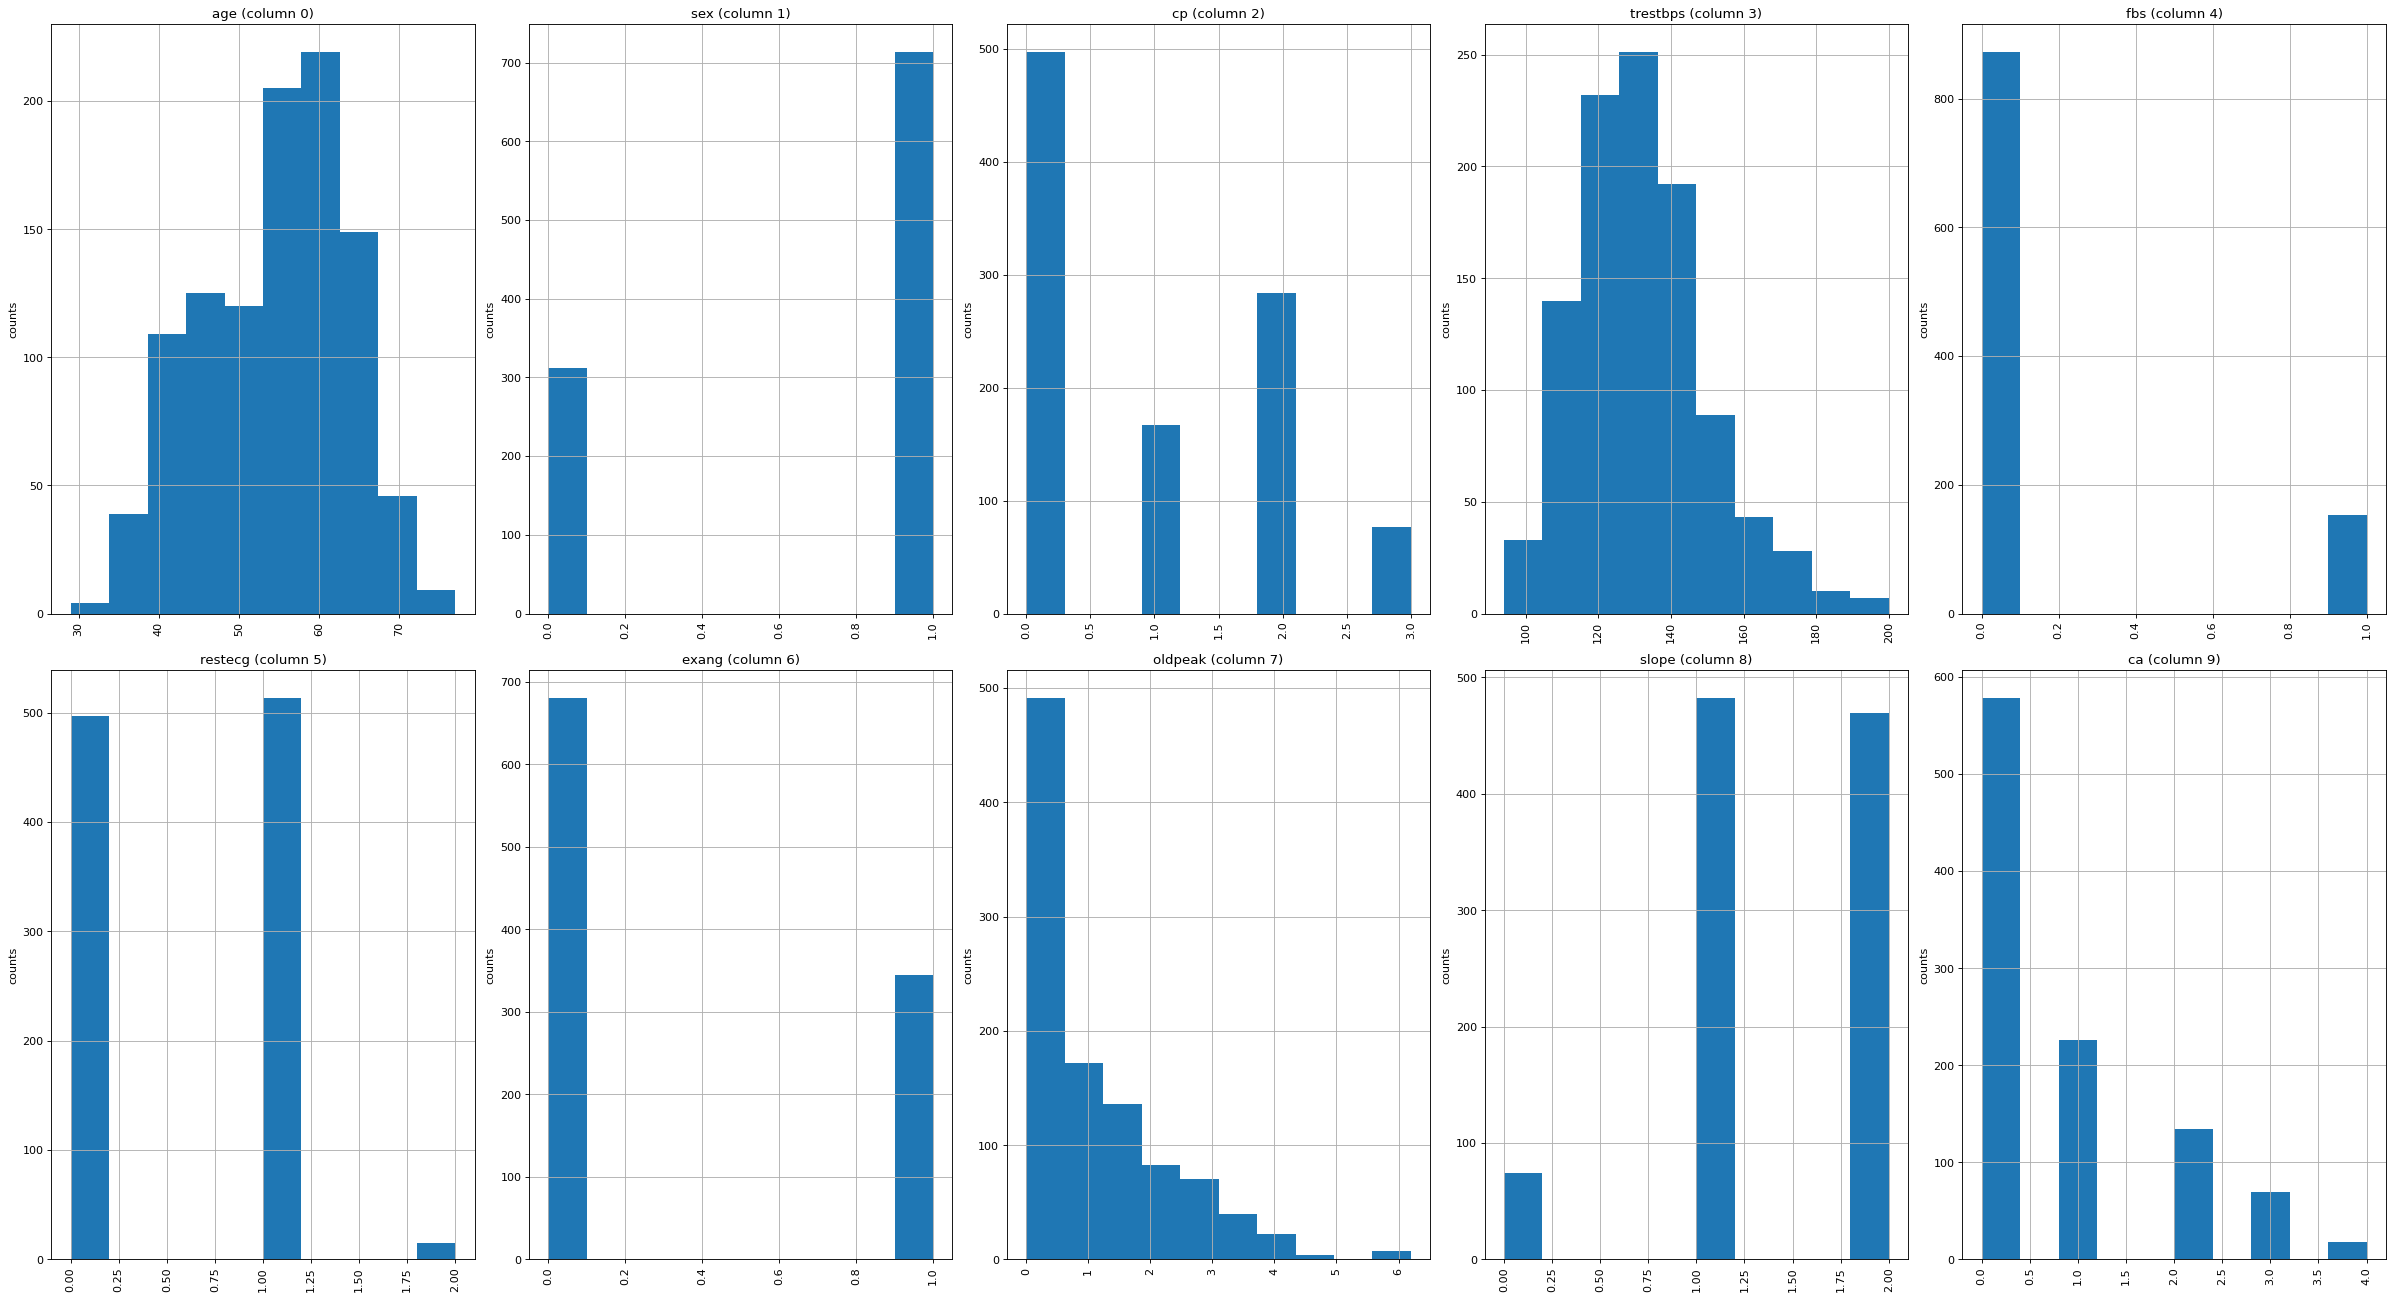

In [7]:
plotPerColumnDistribution(df1, 10, 5)

## Langkah 8: Eksekusi Grafik Matriks Korelasi
Menjalankan matriks korelasi untuk melihat parameter klinis mana yang paling berpengaruh kuat terhadap indikasi penyakit jantung pasien.

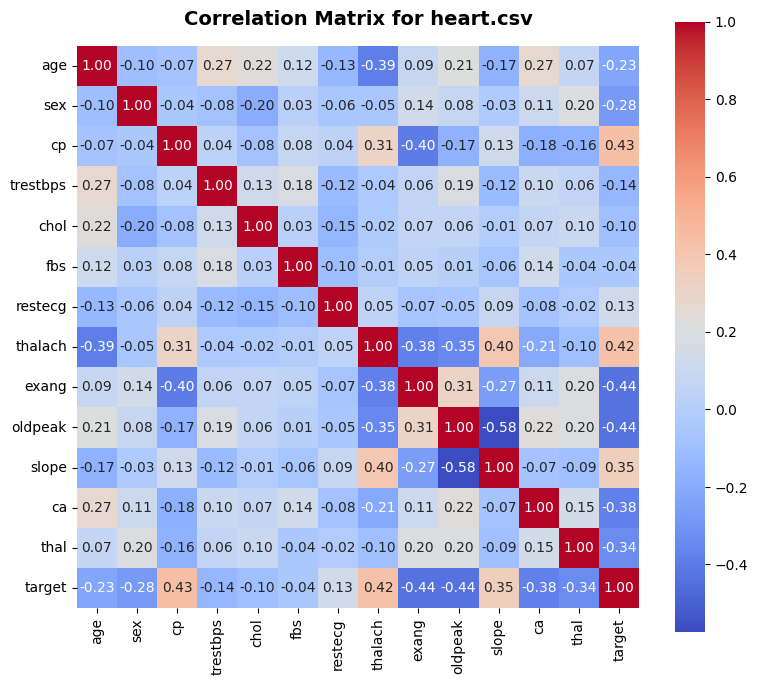

In [8]:
plotCorrelationMatrix(df1, 8)

## Langkah 9: Eksekusi Scatter and Density Plot
Menampilkan representasi sebaran titik data rekam medis secara menyeluruh.

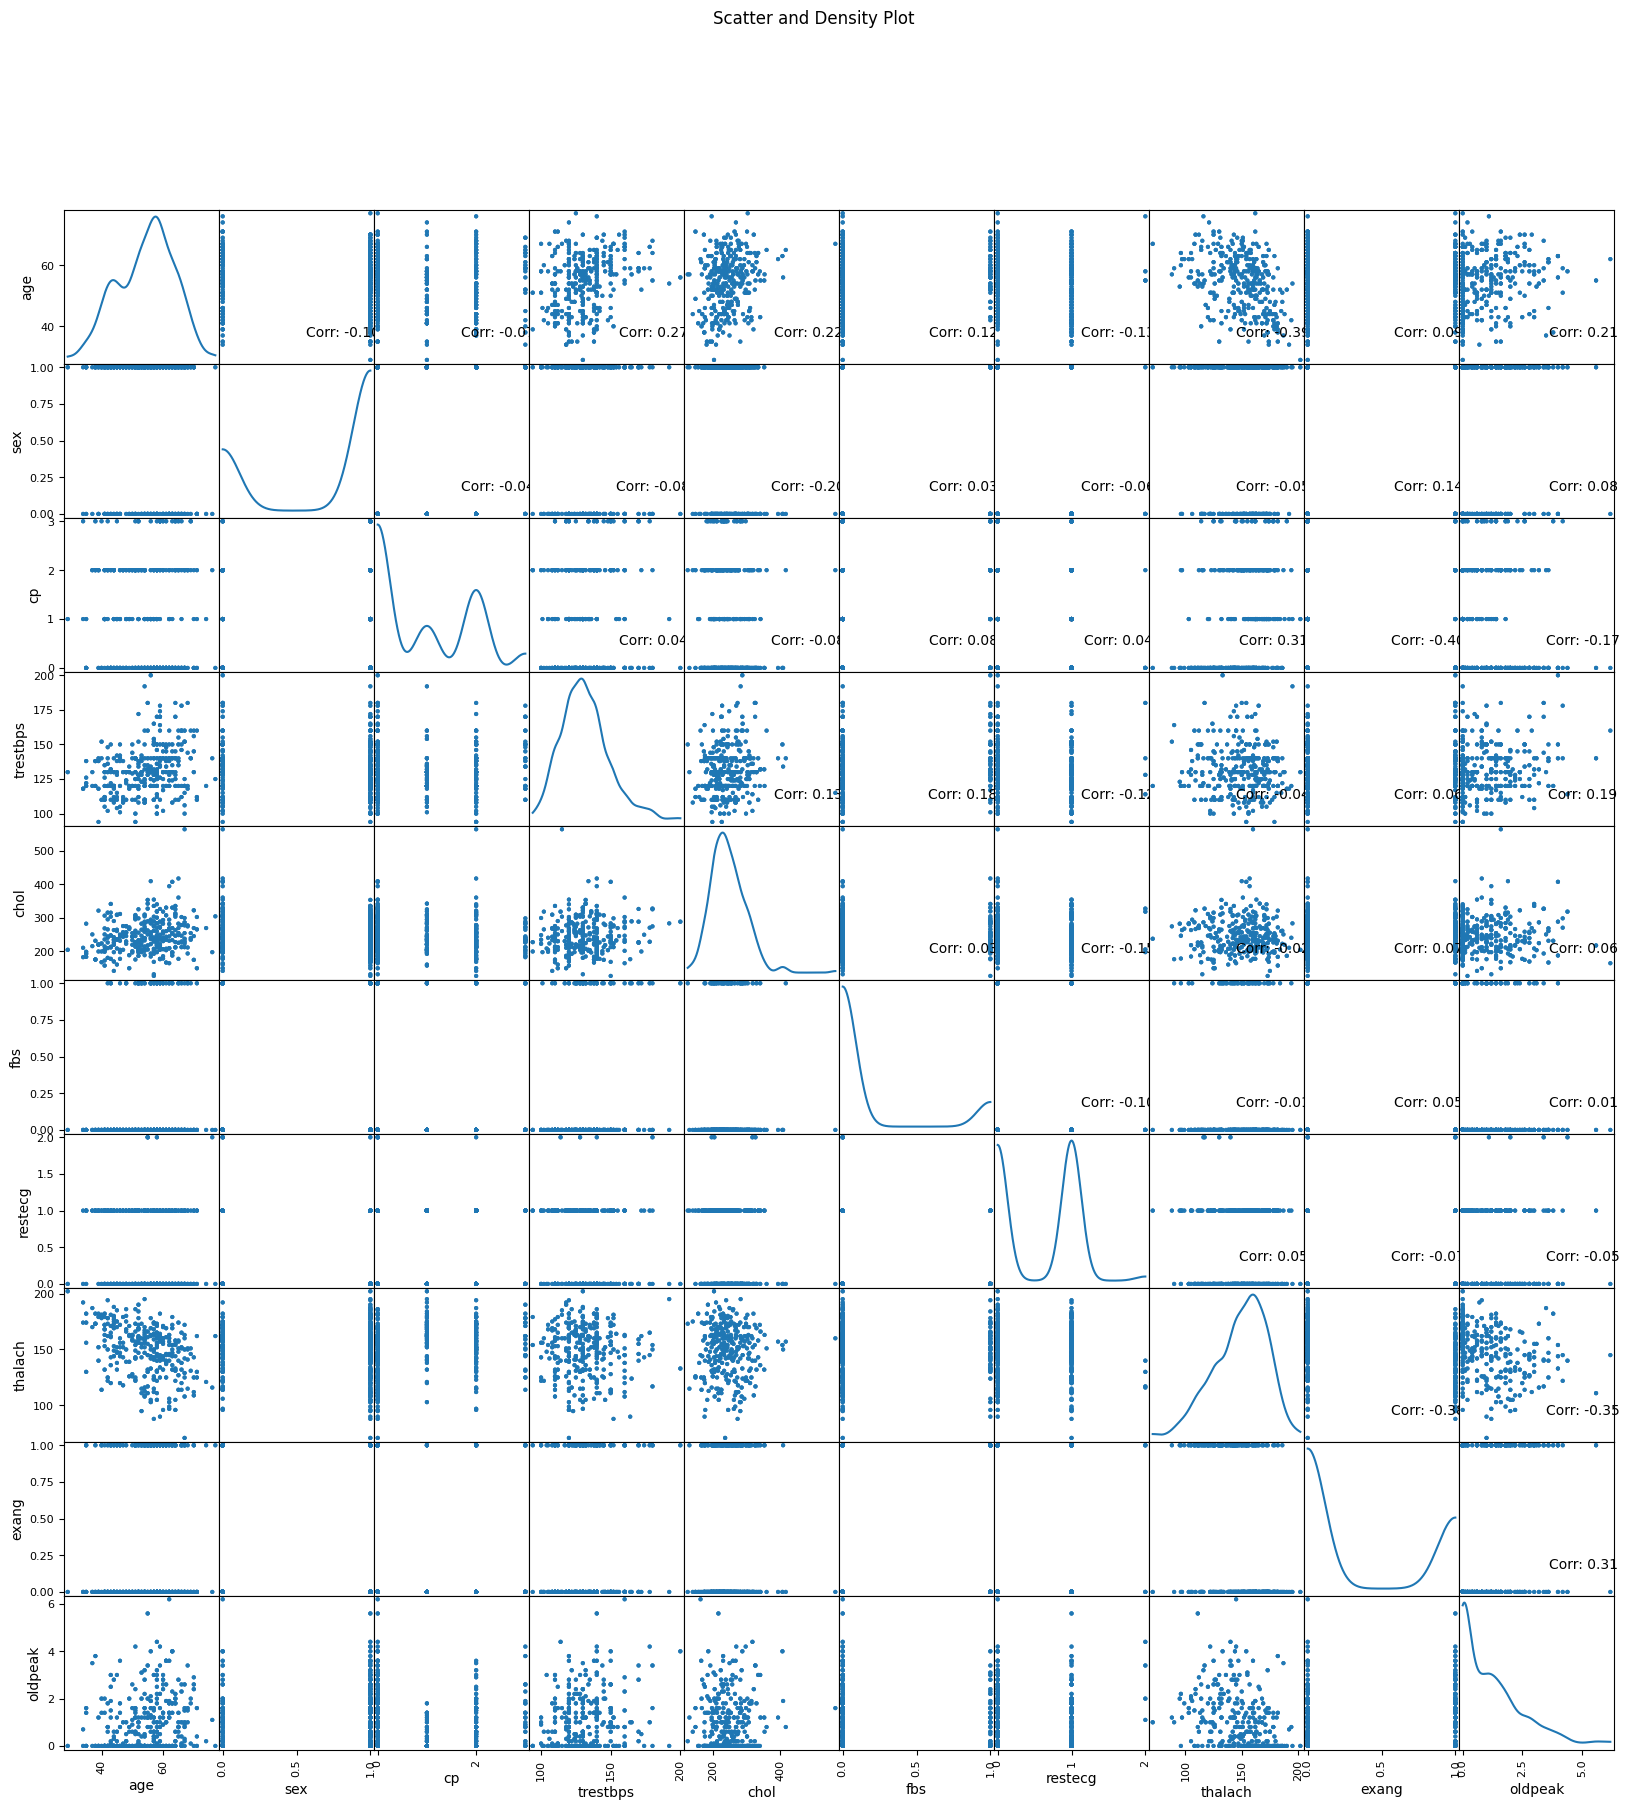

In [9]:
plotScatterMatrix(df1, 20, 10)

# IMPLEMENTASI MACHINE LEARNING (C4.5 & KNN DENGAN GRID SEARCH & CV)

## Langkah 10: Memuat Library Pemodelan & Evaluasi Data Mining
Kita mengimpor pustaka khusus dari `sklearn` yang bertanggung jawab untuk membagi dataset, menormalisasi data berbasis Z-Score, melakukan optimasi parameter (`GridSearchCV`), menghitung skor validasi silang (`cross_val_score`), serta menyajikan metrik evaluasi diagnostik lengkap.

In [10]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler # Z-Score Normalization
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

print("Library untuk validasi, optimasi, dan pemodelan ML berhasil dimuat!")

Library untuk validasi, optimasi, dan pemodelan ML berhasil dimuat!


## Langkah 11: Pemisahan Fitur Medis dan Label Target (Splitting Data)
Kita memisahkan kolom data menjadi Fitur Medis (`X`) dan Label Target penyakit (`y`). Selanjutnya data dibagi secara proporsional menggunakan *Stratified Sampling* dengan rasio **70% data latih (212 sampel)** dan **30% data uji (91 sampel)** sesuai metodologi jurnal.

In [11]:
X = df1.drop(columns=['target'])
y = df1['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Jumlah Data Latih (Training Set 70%): {X_train.shape[0]} sampel")
print(f"Jumlah Data Uji (Testing Set 30%): {X_test.shape[0]} sampel")

Jumlah Data Latih (Training Set 70%): 717 sampel
Jumlah Data Uji (Testing Set 30%): 308 sampel


## Langkah 12: Normalisasi Data Rekam Medis (Z-Score Standardization)
Sesuai dengan spesifikasi dokumen metode, fitur-fitur numerik akan dinormalisasi menggunakan teknik standardisasi (Z-Score) agar memiliki nilai rata-rata (mean) = 0 dan standar deviasi = 1. Langkah ini sangat krusial bagi algoritma berbasis jarak seperti KNN.

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Proses normalisasi data menggunakan Z-Score Standardization selesai dilakukan.")

Proses normalisasi data menggunakan Z-Score Standardization selesai dilakukan.


## Langkah 13: Klasifikasi Menggunakan Algoritma Decision Tree C4.5 (Grid Search & 5-Fold CV)
Kita melakukan pencarian kombinasi hyperparameter terbaik (`max_depth` dan `min_samples_split`) menggunakan `GridSearchCV` dengan skema 5-Fold Cross Validation pada data latih. Model terbaik kemudian diuji menggunakan data uji akhir.

In [13]:
# Inisialisasi model dasar dengan kriteria Entropy (Karakteristik C4.5)
dt_base = DecisionTreeClassifier(criterion='entropy', random_state=42)

# Grid parameter ruang pencarian
dt_param_grid = {
    'max_depth': [4, 6, 8, 10, 12],
    'min_samples_split': [2, 3, 5, 10]
}

# Eksekusi Grid Search 5-Fold CV
dt_grid = GridSearchCV(estimator=dt_base, param_grid=dt_param_grid, cv=5, scoring='accuracy')
dt_grid.fit(X_train, y_train)

c45_model = dt_grid.best_estimator_
print(f"Konfigurasi Parameter Optimal C4.5: {dt_grid.best_params_}")

# Menghitung stabilitas akurasi Cross Validation
cv_scores_c45 = cross_val_score(c45_model, X_train, y_train, cv=5)
print(f"Rata-rata Akurasi CV: {cv_scores_c45.mean() * 100:.2f}% (Std: {cv_scores_c45.std() * 100:.2f}%)")

# Evaluasi data uji
y_pred_c45 = c45_model.predict(X_test)
acc_c45 = accuracy_score(y_test, y_pred_c45)
print(f"Akurasi Pengujian Akhir C4.5: {acc_c45 * 100:.2f}%")

Konfigurasi Parameter Optimal C4.5: {'max_depth': 12, 'min_samples_split': 2}
Rata-rata Akurasi CV: 96.24% (Std: 2.13%)
Akurasi Pengujian Akhir C4.5: 98.05%


## Langkah 14: Klasifikasi Menggunakan Algoritma K-Nearest Neighbor (KNN) (Tuning Nilai K)
Kita melakukan analisis sensitivitas nilai parameter tetangga terdekat pada rentang $K = \{3, 5, 7, 9, 11\}$ menggunakan metrik jarak Euclidean melalui proses Grid Search 5-Fold Cross Validation.

In [14]:
# Inisialisasi model dasar KNN
knn_base = KNeighborsClassifier(metric='euclidean')

# Rentang pencarian nilai K sesuai bab eksperimen jurnal
knn_param_grid = {'n_neighbors': [3, 5, 7, 9, 11]}

# Eksekusi Grid Search pada data yang terstandarisasi
knn_grid = GridSearchCV(estimator=knn_base, param_grid=knn_param_grid, cv=5, scoring='accuracy')
knn_grid.fit(X_train_scaled, y_train)

knn_model = knn_grid.best_estimator_
print(f"Nilai K Paling Optimal Hasil Grid Search: {knn_grid.best_params_}")

# Menghitung stabilitas akurasi Cross Validation KNN
cv_scores_knn = cross_val_score(knn_model, X_train_scaled, y_train, cv=5)
print(f"Rata-rata Akurasi CV KNN: {cv_scores_knn.mean() * 100:.2f}% (Std: {cv_scores_knn.std() * 100:.2f}%)")

# Evaluasi data uji
y_pred_knn = knn_model.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"Akurasi Pengujian Akhir KNN: {acc_knn * 100:.2f}%")

Nilai K Paling Optimal Hasil Grid Search: {'n_neighbors': 3}
Rata-rata Akurasi CV KNN: 89.69% (Std: 3.87%)
Akurasi Pengujian Akhir KNN: 90.58%


## Langkah 15: Visualisasi Grafik Batang Perbandingan Akurasi Akhir
Tahap akhir adalah memvisualisasikan perbandingan performa akurasi pengujian antara Decision Tree C4.5 dengan K-Nearest Neighbor ke dalam grafik batang (*Bar Plot*) beresolusi tinggi untuk keperluan sitasi Figure 1 pada jurnal.

/tmp/ipykernel_4184/623991419.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='Set2')


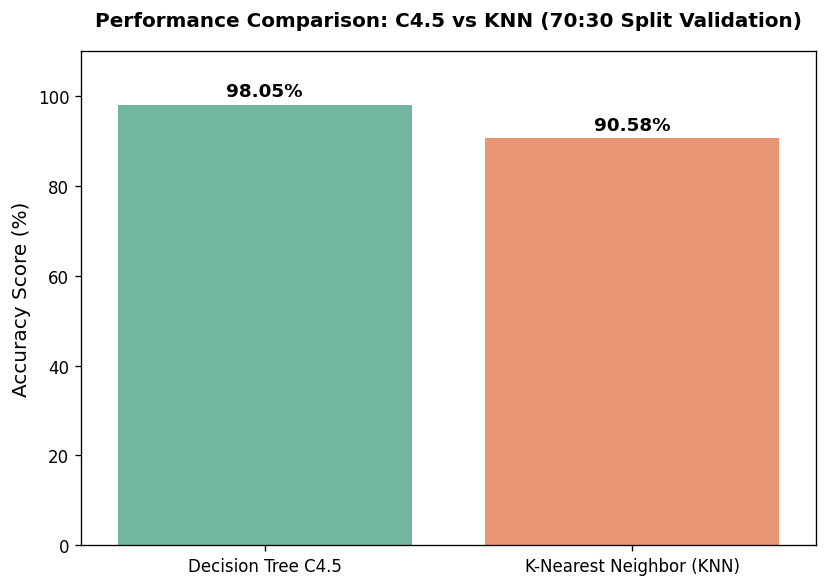

In [15]:
plt.figure(figsize=(7, 5), dpi=120)
models = ['Decision Tree C4.5', 'K-Nearest Neighbor (KNN)']
accuracies = [acc_c45 * 100, acc_knn * 100]

sns.barplot(x=models, y=accuracies, palette='Set2')
plt.ylabel('Accuracy Score (%)', fontsize=12)
plt.title('Performance Comparison: C4.5 vs KNN (70:30 Split Validation)', fontsize=12, pad=15, fontweight='bold')

# Menampilkan label persentase numerik di atas bar grafik
for i, val in enumerate(accuracies):
    plt.text(i, val + 1, f"{val:.2f}%", ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.ylim(0, 110)
plt.tight_layout()
plt.show()